# Toy Model for Relational FERM

This notebook tests the relational FERM mechanism under controlled ground truth.

The goal is not to reproduce the empirical migration data. The goal is methodological:

1. Generate synthetic OD flows from a known relational attractiveness matrix \(\Sigma^\ast\).
2. Compare RM against FERM variants using the correct feature, noisy features, shuffled features, and random features.
3. Calibrate \(\sigma\) on a calibration split using multinomial log-likelihood.
4. Evaluate selected models on an independent test split.
5. Check whether the correct relational feature is recovered robustly.

This directly answers the question: if the data really contain a relational signal, can FERM detect and use it?

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))
(ROOT / ".matplotlib-cache").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))

from ferm.model import FERM, RM

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

FIG_DIR = ROOT / "outputs" / "toy_model_ferm"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved: {path}")

## 1. Experiment Settings

The synthetic network is intentionally simple:

- countries are points in space;
- each country has a population;
- countries belong to latent communities;
- the true relational feature rewards within-community corridors and penalizes between-community corridors;
- observed calibration and test flows are generated from FERM using this true matrix.

The important point is that the true answer is known.

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

N_NODES = 32
N_COMMUNITIES = 4

TRUE_SIGMA = 1.25
TRUE_PARTICLES = 3000
NUM_PARTICLES = 800

SIGMA_GRID = [0.5, 0.8, 1.0, 1.25, 1.6, 2.0, 3.0]

# Independent robustness repetitions. Increase to 20+ for a stronger diagnostic.
ROBUSTNESS_SEEDS = list(range(10))

# Total observed outflow per origin is generated as a small fraction of population.
OUTFLOW_RATE = 0.025
MIN_OUTFLOW = 250
MAX_OUTFLOW = 5000

## 2. Synthetic Network and True Relational Feature

The true \(\Sigma^\ast\) matrix has:

\[
\Sigma^\ast_{ii}=0
\]

and off-diagonal entries \(\Sigma^\ast_{ij}\) that are higher for corridors connecting countries in the same latent community.

After construction, the off-diagonal entries are robustly rescaled so that the central 90% roughly lies in \([-1,1]\). This gives a controlled feature scale.

In [3]:
def robust_rescale_offdiag(Sigma, low_q=0.05, high_q=0.95, target=1.0):
    """Center off-diagonal values and rescale robustly; keep diagonal at zero."""
    S = pd.DataFrame(Sigma).astype(float).copy()
    values = S.to_numpy().copy()
    mask = ~np.eye(values.shape[0], dtype=bool)
    off = values[mask]
    center = np.nanmedian(off)
    q_low, q_high = np.nanquantile(off, [low_q, high_q])
    scale = max(abs(q_low - center), abs(q_high - center), 1e-12)
    values[mask] = target * (off - center) / scale
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=S.index, columns=S.columns)


def make_synthetic_nodes(n_nodes=N_NODES, n_communities=N_COMMUNITIES, rng=rng):
    codes = [f"C{i:02d}" for i in range(n_nodes)]
    communities = np.repeat(np.arange(n_communities), int(np.ceil(n_nodes / n_communities)))[:n_nodes]
    rng.shuffle(communities)

    centers = np.array([
        [-35, 35],
        [35, 35],
        [-35, -35],
        [35, -35],
    ])[:n_communities]

    xy = np.zeros((n_nodes, 2))
    for k in range(n_communities):
        idx = np.where(communities == k)[0]
        xy[idx] = centers[k] + rng.normal(scale=11.0, size=(len(idx), 2))

    # Synthetic lat/lon only for compatibility; distances below use the same coordinates directly.
    lat = xy[:, 1]
    lon = xy[:, 0]

    log_pop = rng.normal(loc=10.4, scale=0.75, size=n_nodes)
    population = np.round(np.exp(log_pop)).astype(int)

    nodes = pd.DataFrame({
        "code": codes,
        "iso3": codes,
        "country_name": [f"Toy country {c}" for c in codes],
        "lat": lat,
        "lon": lon,
        "population": population,
        "community": communities,
    })
    return nodes


def make_distance_matrix(nodes):
    coords = nodes.set_index("iso3")[["lon", "lat"]].to_numpy(dtype=float)
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt((diff ** 2).sum(axis=2))
    np.fill_diagonal(D, 0.0)
    return pd.DataFrame(D, index=nodes["iso3"], columns=nodes["iso3"])


def make_true_sigma(nodes, rng):
    codes = nodes["iso3"].tolist()
    comm = nodes.set_index("iso3")["community"]
    n = len(codes)
    raw = pd.DataFrame(0.0, index=codes, columns=codes)

    for i in codes:
        for j in codes:
            if i == j:
                continue
            same = comm.loc[i] == comm.loc[j]
            raw.loc[i, j] = 1.0 if same else -0.65

    # Add a small directional bridge structure so the truth is not only block-diagonal.
    bridge_origins = nodes.sort_values("population", ascending=False).head(4)["iso3"].tolist()
    bridge_dests = nodes.sort_values("population", ascending=False).iloc[4:8]["iso3"].tolist()
    for i in bridge_origins:
        for j in bridge_dests:
            if i != j:
                raw.loc[i, j] += 0.75

    raw += rng.normal(scale=0.12, size=raw.shape)
    for k in range(n):
        raw.iat[k, k] = 0.0
    return robust_rescale_offdiag(raw)


nodes = make_synthetic_nodes()
D = make_distance_matrix(nodes)
Sigma_true = make_true_sigma(nodes, rng)

print(nodes.head())
print("nodes:", len(nodes))
print("distance range:", float(D.to_numpy()[~np.eye(len(D), dtype=bool)].min()), float(D.to_numpy().max()))
print("true Sigma offdiag p05, median, p95:")
vals = Sigma_true.to_numpy()[~np.eye(len(Sigma_true), dtype=bool)]
print(np.quantile(vals, [0.05, 0.5, 0.95]))

  code iso3     country_name        lat        lon  population  community
0  C00  C00  Toy country C00 -38.835976  43.726820       20001          3
1  C01  C01  Toy country C01 -31.819687 -34.256630       25027          2
2  C02  C02  Toy country C02  44.662953 -45.547709       24679          0
3  C03  C03  Toy country C03 -25.562265  29.914130       13401          3
4  C04  C04  Toy country C04 -49.032550  32.895652       47346          3
nodes: 32
distance range: 1.4235184313338214 124.75781249357445
true Sigma offdiag p05, median, p95:
[-0.13119625  0.          1.        ]


saved: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/toy_model_ferm/01_synthetic_network_and_true_sigma.png


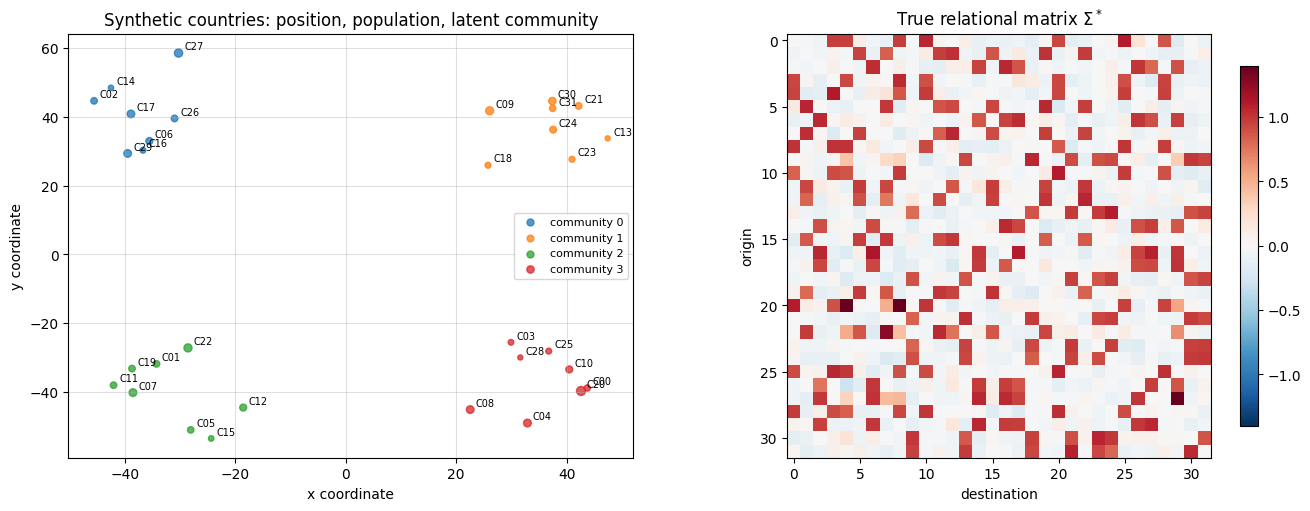

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for k, g in nodes.groupby("community"):
    axes[0].scatter(g["lon"], g["lat"], s=np.sqrt(g["population"]) / 7, label=f"community {k}", alpha=0.75)
for _, r in nodes.iterrows():
    axes[0].text(r["lon"] + 1, r["lat"] + 1, r["iso3"], fontsize=7)
axes[0].set_title("Synthetic countries: position, population, latent community")
axes[0].set_xlabel("x coordinate")
axes[0].set_ylabel("y coordinate")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

im = axes[1].imshow(Sigma_true.to_numpy(), cmap="RdBu_r", vmin=-1.4, vmax=1.4)
axes[1].set_title(r"True relational matrix $\Sigma^*$")
axes[1].set_xlabel("destination")
axes[1].set_ylabel("origin")
fig.colorbar(im, ax=axes[1], shrink=0.85)
savefig("01_synthetic_network_and_true_sigma")
plt.show()

## 3. Generate Synthetic Calibration and Test Flows

First FERM is run with the true \(\Sigma^\ast\) and true \(\sigma\), producing the ground-truth probability matrix \(P^\ast\).

Then two independent datasets are drawn from the same probabilities:

\[
O_i^{cal} \sim \mathrm{Multinomial}(N_i, P_i^\ast)
\]

\[
O_i^{test} \sim \mathrm{Multinomial}(N_i, P_i^\ast)
\]

This means calibration and test share the same data-generating mechanism, but are independent samples.

In [5]:
def all_zero_flows(nodes):
    rows = []
    codes = nodes["iso3"].tolist()
    for i in codes:
        for j in codes:
            if i != j:
                rows.append({"country_from": i, "country_to": j, "num_migrants": 0})
    return pd.DataFrame(rows)


def generate_probability_matrix_from_ferm(nodes, distance_matrix, Sigma, sigma, num_particles, rng):
    dummy = all_zero_flows(nodes)
    result = FERM(
        nodes=nodes,
        flows=dummy,
        features=Sigma,
        distance_matrix=distance_matrix,
    ).run(num_particles=num_particles, sigma=sigma, rng=rng)
    P = result.probability_matrix.copy()
    # Numerical guard: make every row stochastic over non-diagonal destinations.
    P = P.clip(lower=0.0)
    for k in range(len(P)):
        P.iat[k, k] = 0.0
    P = P.div(P.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return P


def make_origin_totals(nodes, rng):
    totals = np.round(nodes["population"].to_numpy() * OUTFLOW_RATE).astype(int)
    totals = np.clip(totals, MIN_OUTFLOW, MAX_OUTFLOW)
    # Add modest origin-level noise; evaluation will condition on realized totals anyway.
    totals = rng.poisson(totals).clip(MIN_OUTFLOW, MAX_OUTFLOW)
    return pd.Series(totals, index=nodes["iso3"], name="N_i")


def sample_flows_from_probabilities(P, origin_totals, rng):
    rows = []
    codes = list(P.index)
    for origin in codes:
        probs = P.loc[origin].to_numpy(dtype=float).copy()
        probs[codes.index(origin)] = 0.0
        if probs.sum() <= 0:
            probs = np.ones(len(codes), dtype=float)
            probs[codes.index(origin)] = 0.0
        probs = probs / probs.sum()
        counts = rng.multinomial(int(origin_totals.loc[origin]), probs)
        for dest, count in zip(codes, counts):
            if origin != dest:
                rows.append({"country_from": origin, "country_to": dest, "num_migrants": int(count)})
    return pd.DataFrame(rows)


P_true = generate_probability_matrix_from_ferm(
    nodes=nodes,
    distance_matrix=D,
    Sigma=Sigma_true,
    sigma=TRUE_SIGMA,
    num_particles=TRUE_PARTICLES,
    rng=np.random.default_rng(SEED + 100),
)
origin_totals = make_origin_totals(nodes, np.random.default_rng(SEED + 200))
flows_cal = sample_flows_from_probabilities(P_true, origin_totals, np.random.default_rng(SEED + 300))
flows_test = sample_flows_from_probabilities(P_true, origin_totals, np.random.default_rng(SEED + 400))

print("Calibration total migrants:", flows_cal["num_migrants"].sum())
print("Test total migrants:", flows_test["num_migrants"].sum())
print("Mean nonzero route share, calibration:", (flows_cal["num_migrants"] > 0).mean())
display(flows_cal.head())

Calibration total migrants: 25048
Test total migrants: 25048
Mean nonzero route share, calibration: 0.14717741935483872


,country_from,country_to,num_migrants
0,C00,C01,0
1,C00,C02,0
2,C00,C03,0
3,C00,C04,0
4,C00,C05,0


## 4. Candidate Features

We test several candidate \(\Sigma\) matrices:

- **correct feature**: the true data-generating matrix;
- **mildly noisy feature**: true matrix plus moderate noise;
- **strongly noisy feature**: true matrix plus stronger noise;
- **shuffled feature**: same marginal distribution but wrong OD assignment;
- **anti feature**: wrong sign of the true signal;
- **random feature**: unrelated matrix.

If FERM is behaving correctly, the correct/noisy features should beat RM and wrong features should not.

In [6]:
def make_candidate_features(Sigma_true, rng):
    codes = Sigma_true.index.tolist()
    n = len(codes)
    mask = ~np.eye(n, dtype=bool)
    true_vals = Sigma_true.to_numpy()

    noisy_mild = true_vals + rng.normal(scale=0.25, size=true_vals.shape)
    noisy_strong = true_vals + rng.normal(scale=0.75, size=true_vals.shape)

    shuffled = true_vals.copy()
    off = shuffled[mask].copy()
    rng.shuffle(off)
    shuffled[mask] = off

    anti = -true_vals

    random = rng.normal(size=true_vals.shape)

    candidates = {
        "correct": ("FERM: correct relational feature", Sigma_true.copy()),
        "noisy_mild": ("FERM: mildly noisy feature", robust_rescale_offdiag(pd.DataFrame(noisy_mild, index=codes, columns=codes))),
        "noisy_strong": ("FERM: strongly noisy feature", robust_rescale_offdiag(pd.DataFrame(noisy_strong, index=codes, columns=codes))),
        "shuffled": ("FERM: shuffled feature", robust_rescale_offdiag(pd.DataFrame(shuffled, index=codes, columns=codes))),
        "anti": ("FERM: anti feature", robust_rescale_offdiag(pd.DataFrame(anti, index=codes, columns=codes))),
        "random": ("FERM: random feature", robust_rescale_offdiag(pd.DataFrame(random, index=codes, columns=codes))),
    }
    return candidates


FEATURES = make_candidate_features(Sigma_true, np.random.default_rng(SEED + 500))
print(list(FEATURES.keys()))

['correct', 'noisy_mild', 'noisy_strong', 'shuffled', 'anti', 'random']


## 5. Metrics

The calibration criterion is the conditional multinomial negative log-likelihood:

\[
-\log L(M) = -\sum_i\sum_j O_{ij}\log p^M_{ij}
\]

where the origin total \(N_i\) is fixed. Lower is better.

The notebook also reports:

- median absolute log-ratio error;
- share of routes better than RM;
- log-scale predictive \(R^2\);
- chi-square diagnostic;
- bits saved per migrant relative to RM.

In [7]:
EPS = 1e-12
CHI2_EXPECTED_FLOOR = 1.0


def log10p(x):
    return np.log10(np.asarray(x, dtype=float) + 1.0)


def prepare_comp(comp):
    out = comp.copy()
    if "total_migrants" in out.columns and "num_migrants" not in out.columns:
        out = out.rename(columns={"total_migrants": "num_migrants"})
    return out


def predictive_r2_from_logs(obs_log, pred_log):
    obs = np.asarray(obs_log, dtype=float)
    pred = np.asarray(pred_log, dtype=float)
    denom = np.sum((obs - obs.mean()) ** 2)
    if denom <= 0:
        return np.nan
    return 1.0 - np.sum((obs - pred) ** 2) / denom


def probability_from_comparison(comp):
    df = prepare_comp(comp).copy()
    pred_sum = df.groupby("country_from")["predicted_migrants"].transform("sum")
    n_dest = df.groupby("country_from")["country_to"].transform("count")
    df["p_model"] = np.where(pred_sum > 0, df["predicted_migrants"] / pred_sum, 1.0 / n_dest)
    df["p_model"] = df["p_model"].clip(lower=EPS)
    return df


def multinomial_nll_bits(comp):
    df = probability_from_comparison(comp)
    y = df["num_migrants"].to_numpy(dtype=float)
    p = df["p_model"].to_numpy(dtype=float)
    nll_bits = -np.sum(y * np.log2(p))
    total = y.sum()
    return nll_bits, nll_bits / total if total > 0 else np.nan


def summarize_comp(comp, label, model_key, rm_comp=None, sigma=np.nan):
    c = prepare_comp(comp)
    obs = c["num_migrants"].astype(float)
    pred = c["predicted_migrants"].astype(float)
    obs_log = log10p(obs)
    pred_log = log10p(pred)
    nll_bits, nll_bpm = multinomial_nll_bits(c)

    row = {
        "model": model_key,
        "label": label,
        "sigma": sigma,
        "total_migrants": obs.sum(),
        "median_abs_log_ratio": np.median(np.abs(pred_log - obs_log)),
        "mean_abs_log_ratio": np.mean(np.abs(pred_log - obs_log)),
        "MAE": np.mean(np.abs(pred - obs)),
        "RMSE": np.sqrt(np.mean((pred - obs) ** 2)),
        "chi2": np.sum(((obs - pred) ** 2) / np.maximum(pred, CHI2_EXPECTED_FLOOR)),
        "chi2_per_route": np.mean(((obs - pred) ** 2) / np.maximum(pred, CHI2_EXPECTED_FLOOR)),
        "Pearson_log": pd.Series(obs_log).corr(pd.Series(pred_log), method="pearson"),
        "R2_log": predictive_r2_from_logs(obs_log, pred_log),
        "nll_bits": nll_bits,
        "nll_bits_per_migrant": nll_bpm,
    }

    if rm_comp is not None:
        rm = prepare_comp(rm_comp)
        merged = c[["country_from", "country_to", "num_migrants", "predicted_migrants"]].merge(
            rm[["country_from", "country_to", "predicted_migrants"]].rename(columns={"predicted_migrants": "pred_rm"}),
            on=["country_from", "country_to"],
            how="inner",
        )
        model_err = np.abs(log10p(merged["predicted_migrants"]) - log10p(merged["num_migrants"]))
        rm_err = np.abs(log10p(merged["pred_rm"]) - log10p(merged["num_migrants"]))
        rm_nll, rm_nll_bpm = multinomial_nll_bits(rm)
        row.update({
            "median_improvement_abs_log_vs_RM": np.median(rm_err - model_err),
            "share_better_than_RM": np.mean(model_err < rm_err),
            "R2_log_gain_vs_RM": row["R2_log"] - summarize_comp(rm, "RM", "rm")["R2_log"],
            "bits_saved_per_migrant_vs_RM": rm_nll_bpm - nll_bpm,
            "bits_saved_total_vs_RM": rm_nll - nll_bits,
        })
    return row

## 6. Calibration on Synthetic Calibration Data

RM has no \(\sigma\). For every FERM feature candidate, \(\sigma\) is selected by minimizing multinomial negative log-likelihood on the calibration split.

In [8]:
def run_rm(flows):
    return RM(nodes=nodes, flows=flows, distance_matrix=D).run()


def run_ferm(flows, Sigma, sigma, seed):
    return FERM(nodes=nodes, flows=flows, features=Sigma, distance_matrix=D).run(
        num_particles=NUM_PARTICLES,
        sigma=sigma,
        rng=np.random.default_rng(seed),
    )


rm_cal = run_rm(flows_cal)
rm_test = run_rm(flows_test)

calibration_rows = [summarize_comp(rm_cal.comparison, "RM", "rm", sigma=np.nan)]
calibration_results = {"rm": {"result": rm_cal, "label": "RM"}}

run_id = 0
for feature_key, (label, Sigma) in FEATURES.items():
    for sigma in SIGMA_GRID:
        run_id += 1
        result = run_ferm(flows_cal, Sigma, sigma=sigma, seed=SEED + 1000 + run_id)
        row = summarize_comp(result.comparison, label, feature_key, rm_comp=rm_cal.comparison, sigma=sigma)
        calibration_rows.append(row)
        calibration_results[(feature_key, sigma)] = {"result": result, "label": label}

calibration_df = pd.DataFrame(calibration_rows)

best_by_feature = (
    calibration_df[calibration_df["model"] != "rm"]
    .sort_values(["model", "nll_bits_per_migrant"])
    .groupby("model", as_index=False)
    .first()
    .sort_values("nll_bits_per_migrant")
)

display(best_by_feature[[
    "model", "label", "sigma", "nll_bits_per_migrant", "bits_saved_per_migrant_vs_RM",
    "median_improvement_abs_log_vs_RM", "share_better_than_RM", "R2_log_gain_vs_RM"
]])

,model,label,sigma,nll_bits_per_migrant,bits_saved_per_migrant_vs_RM,median_improvement_abs_log_vs_RM,share_better_than_RM,R2_log_gain_vs_RM
1,correct,FERM: correct relational feature,1.25,0.435070,1.042410,0.468950,0.994960,1.548697
2,noisy_mild,FERM: mildly noisy feature,1.25,0.487632,0.989848,0.455188,0.988911,1.507275
3,noisy_strong,FERM: strongly noisy feature,1.60,0.778358,0.699122,0.334444,0.927419,1.192583
5,shuffled,FERM: shuffled feature,3.00,1.389429,0.088051,0.126607,0.732863,0.365645
4,random,FERM: random feature,3.00,1.568395,-0.090915,0.109464,0.685484,0.248220
0,anti,FERM: anti feature,3.00,2.908644,-1.431164,-0.191039,0.225806,-1.232033


saved: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/toy_model_ferm/02_calibration_curves.png


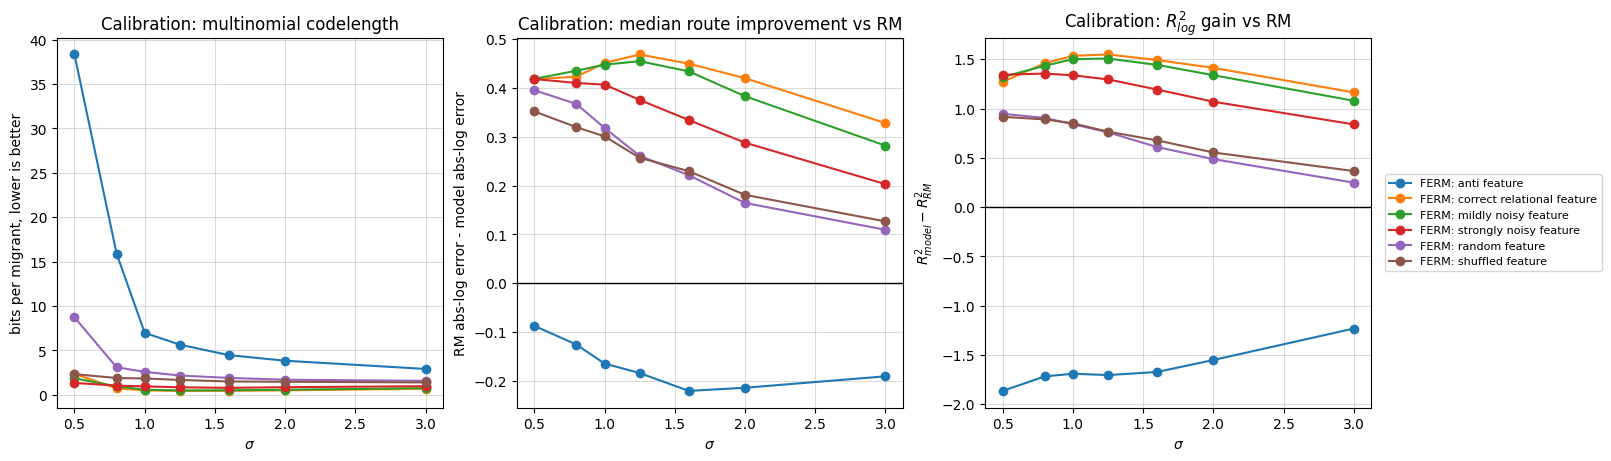

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
plot_df = calibration_df[calibration_df["model"] != "rm"].copy()

for model_key, g in plot_df.groupby("model"):
    label = g["label"].iloc[0]
    g = g.sort_values("sigma")
    axes[0].plot(g["sigma"], g["nll_bits_per_migrant"], marker="o", label=label)
    axes[1].plot(g["sigma"], g["median_improvement_abs_log_vs_RM"], marker="o", label=label)
    axes[2].plot(g["sigma"], g["R2_log_gain_vs_RM"], marker="o", label=label)

axes[0].set_title("Calibration: multinomial codelength")
axes[0].set_ylabel("bits per migrant, lower is better")
axes[1].set_title("Calibration: median route improvement vs RM")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("RM abs-log error - model abs-log error")
axes[2].set_title(r"Calibration: $R^2_{log}$ gain vs RM")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_ylabel(r"$R^2_{model}-R^2_{RM}$")

for ax in axes:
    ax.set_xlabel(r"$\sigma$")
    ax.grid(True, alpha=0.45)

axes[2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
savefig("02_calibration_curves")
plt.show()

## 7. Test Evaluation

The selected \(\sigma\) for each feature is now evaluated on an independent synthetic test split.

If the experiment works, the correct feature should dominate the wrong/shuffled/random features on test data.

In [10]:
test_rows = [summarize_comp(rm_test.comparison, "RM", "rm", sigma=np.nan)]
test_results = {"rm": {"result": rm_test, "label": "RM", "sigma": np.nan}}

for _, best in best_by_feature.iterrows():
    model_key = best["model"]
    label, Sigma = FEATURES[model_key]
    sigma = float(best["sigma"])
    result = run_ferm(flows_test, Sigma, sigma=sigma, seed=SEED + 5000 + int(100 * sigma) + len(test_rows))
    row = summarize_comp(result.comparison, label, model_key, rm_comp=rm_test.comparison, sigma=sigma)
    test_rows.append(row)
    test_results[model_key] = {"result": result, "label": label, "sigma": sigma}

# Oracle: same feature and same sigma used to generate the data, evaluated with finite particles.
oracle = run_ferm(flows_test, Sigma_true, sigma=TRUE_SIGMA, seed=SEED + 9000)
oracle_row = summarize_comp(oracle.comparison, "FERM: correct feature, true sigma", "oracle_true_sigma", rm_comp=rm_test.comparison, sigma=TRUE_SIGMA)
test_rows.append(oracle_row)
test_results["oracle_true_sigma"] = {"result": oracle, "label": "FERM: correct feature, true sigma", "sigma": TRUE_SIGMA}

test_summary = pd.DataFrame(test_rows).sort_values("nll_bits_per_migrant")
display(test_summary[[
    "model", "label", "sigma", "nll_bits_per_migrant", "bits_saved_per_migrant_vs_RM",
    "median_improvement_abs_log_vs_RM", "share_better_than_RM", "R2_log", "R2_log_gain_vs_RM",
    "chi2_per_route"
]])

,model,label,sigma,nll_bits_per_migrant,bits_saved_per_migrant_vs_RM,median_improvement_abs_log_vs_RM,share_better_than_RM,R2_log,R2_log_gain_vs_RM,chi2_per_route
1,correct,FERM: correct relational feature,1.25,0.433490,1.044549,0.472366,0.994960,0.965136,1.530076,0.271516
7,oracle_true_sigma,"FERM: correct feature, true sigma",1.25,0.445985,1.032054,0.467335,0.994960,0.959716,1.524657,0.380755
2,noisy_mild,FERM: mildly noisy feature,1.25,0.477414,1.000626,0.452993,0.991935,0.928991,1.493932,1.869140
3,noisy_strong,FERM: strongly noisy feature,1.60,0.856973,0.621066,0.334444,0.923387,0.591493,1.156434,12.903429
4,shuffled,FERM: shuffled feature,3.00,1.425519,0.052520,0.127146,0.736895,-0.197100,0.367840,39.779312
0,rm,RM,NaN,1.478040,NaN,NaN,NaN,-0.564940,NaN,39.016918
5,random,FERM: random feature,3.00,1.568625,-0.090585,0.094578,0.669355,-0.315463,0.249477,57.900690
6,anti,FERM: anti feature,3.00,2.943158,-1.465118,-0.185106,0.225806,-1.772391,-1.207451,183.677239


saved: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/toy_model_ferm/03_test_summary.png


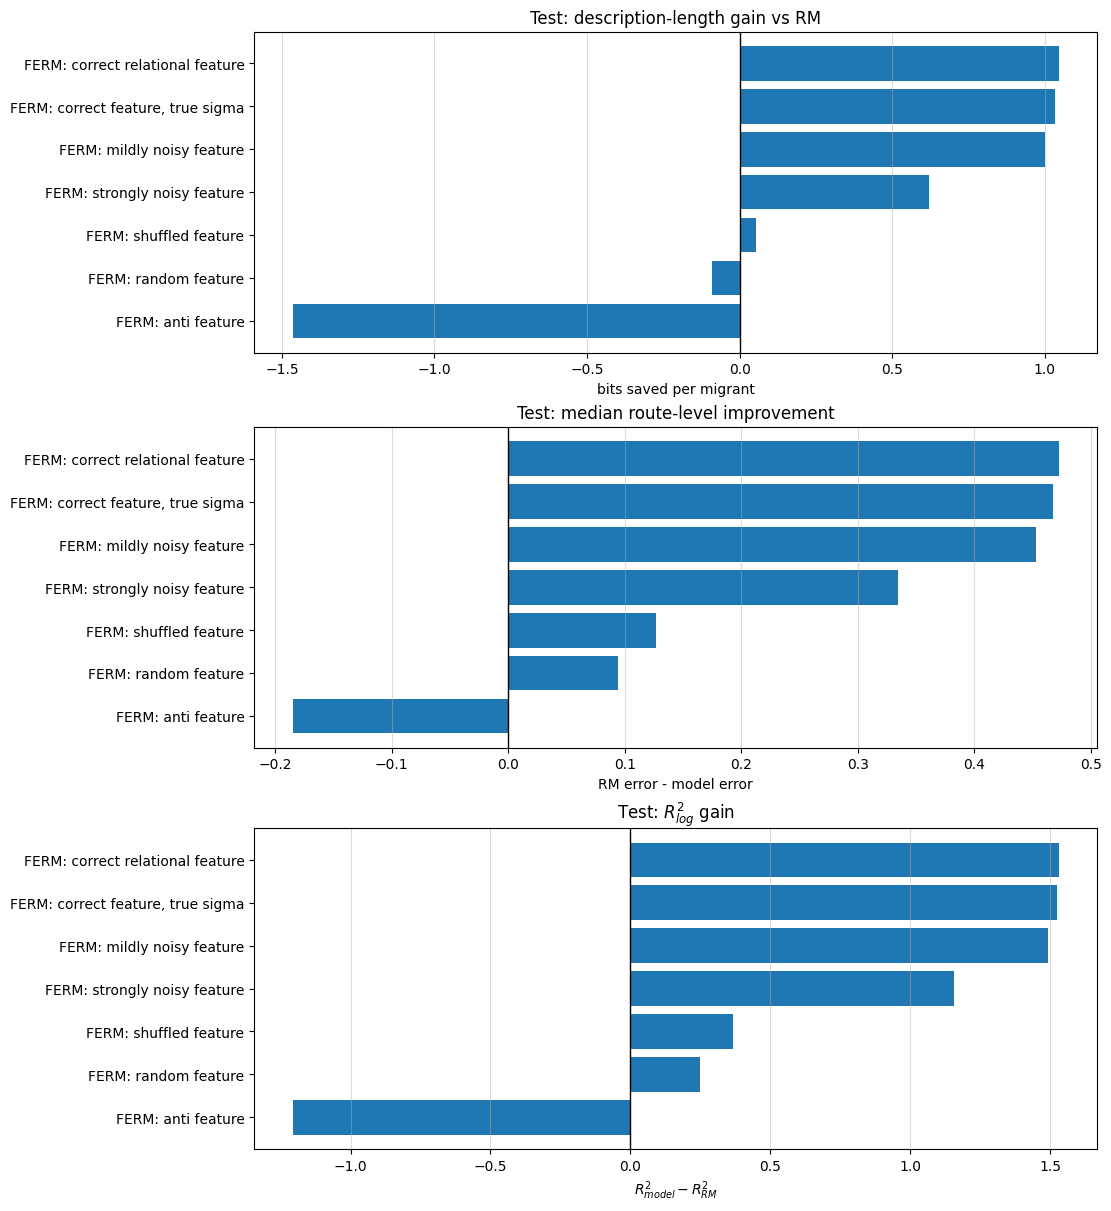

In [15]:
plot_df = test_summary[test_summary["model"] != "rm"].sort_values("bits_saved_per_migrant_vs_RM")
fig, axes = plt.subplots(3, 1, figsize=(11, 12), constrained_layout=True)

axes[0].barh(plot_df["label"], plot_df["bits_saved_per_migrant_vs_RM"])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Test: description-length gain vs RM")
axes[0].set_xlabel("bits saved per migrant")

axes[1].barh(plot_df["label"], plot_df["median_improvement_abs_log_vs_RM"])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Test: median route-level improvement")
axes[1].set_xlabel("RM error - model error")

axes[2].barh(plot_df["label"], plot_df["R2_log_gain_vs_RM"])
axes[2].axvline(0, color="black", linewidth=1)
axes[2].set_title(r"Test: $R^2_{log}$ gain")
axes[2].set_xlabel(r"$R^2_{model}-R^2_{RM}$")

for ax in axes:
    ax.grid(True, axis="x", alpha=0.45)

savefig("03_test_summary")
plt.show()

saved: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/toy_model_ferm/04_route_error_scatter.png


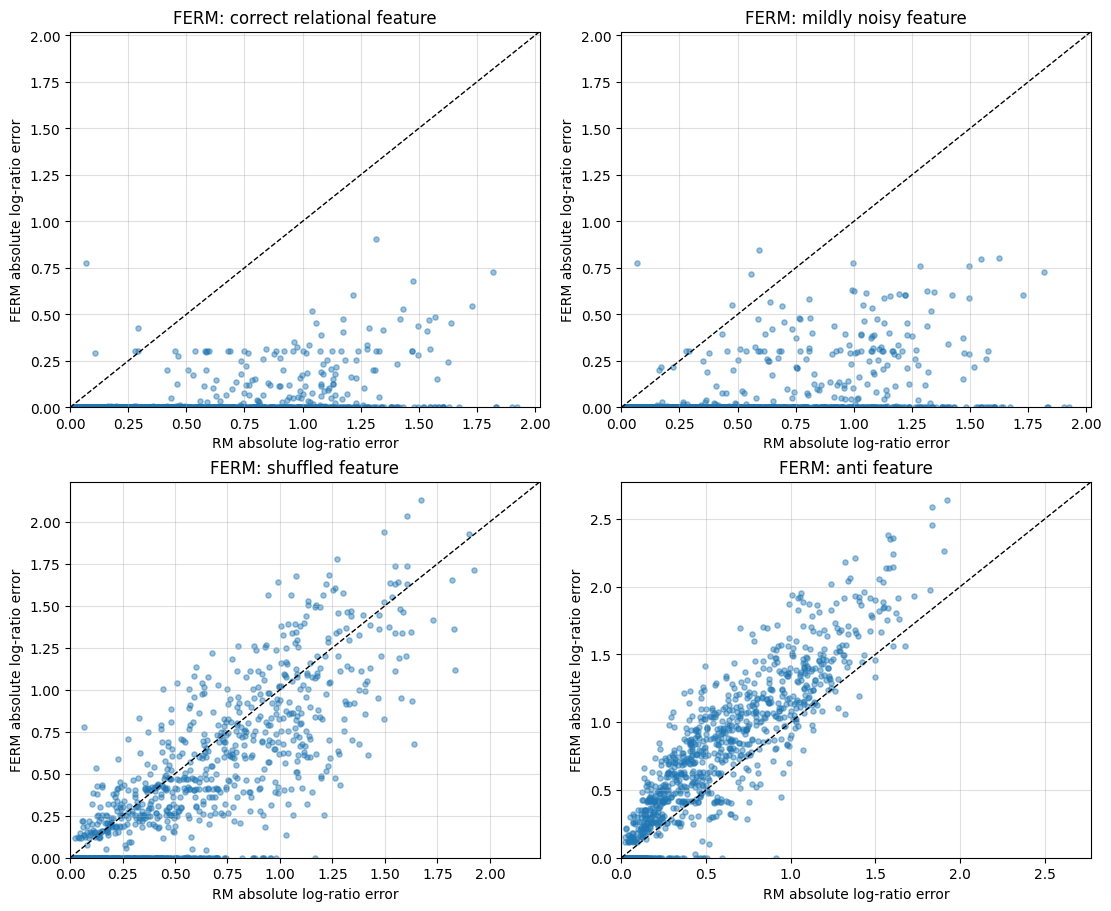

In [12]:
def merged_errors_vs_rm(model_key):
    rm = prepare_comp(test_results["rm"]["result"].comparison)
    model = prepare_comp(test_results[model_key]["result"].comparison)
    merged = rm[["country_from", "country_to", "num_migrants", "predicted_migrants", "abs_log_ratio"]].rename(columns={
        "predicted_migrants": "pred_rm",
        "abs_log_ratio": "abs_log_rm",
    }).merge(
        model[["country_from", "country_to", "predicted_migrants", "abs_log_ratio"]].rename(columns={
            "predicted_migrants": "pred_model",
            "abs_log_ratio": "abs_log_model",
        }),
        on=["country_from", "country_to"],
        how="inner",
    )
    merged["improvement"] = merged["abs_log_rm"] - merged["abs_log_model"]
    return merged

keys_to_plot = ["correct", "noisy_mild", "shuffled", "anti"]
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
axes = axes.ravel()

for ax, key in zip(axes, keys_to_plot):
    if key not in test_results:
        ax.axis("off")
        continue
    df = merged_errors_vs_rm(key)
    ax.scatter(df["abs_log_rm"], df["abs_log_model"], s=14, alpha=0.45)
    lim = max(df["abs_log_rm"].max(), df["abs_log_model"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color="black", linestyle="--", linewidth=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(test_results[key]["label"])
    ax.set_xlabel("RM absolute log-ratio error")
    ax.set_ylabel("FERM absolute log-ratio error")
    ax.grid(True, alpha=0.4)

savefig("04_route_error_scatter")
plt.show()

## 8. Robustness Diagnostic

This repeats the experiment over several independent synthetic samples.

The main quantity is how often each feature is selected as the best model according to test codelength.

If the correct feature is not usually selected, then either the signal is too weak, the simulation is too noisy, or the model cannot recover the relational structure.

In [13]:
def one_toy_repetition(rep_seed, verbose=False):
    local_rng = np.random.default_rng(rep_seed)
    local_nodes = make_synthetic_nodes(rng=local_rng)
    local_D = make_distance_matrix(local_nodes)
    local_Sigma_true = make_true_sigma(local_nodes, local_rng)
    local_features = make_candidate_features(local_Sigma_true, np.random.default_rng(rep_seed + 1))

    P = generate_probability_matrix_from_ferm(
        nodes=local_nodes,
        distance_matrix=local_D,
        Sigma=local_Sigma_true,
        sigma=TRUE_SIGMA,
        num_particles=TRUE_PARTICLES,
        rng=np.random.default_rng(rep_seed + 2),
    )
    totals = make_origin_totals(local_nodes, np.random.default_rng(rep_seed + 3))
    f_cal = sample_flows_from_probabilities(P, totals, np.random.default_rng(rep_seed + 4))
    f_test = sample_flows_from_probabilities(P, totals, np.random.default_rng(rep_seed + 5))

    def local_rm(flows):
        return RM(nodes=local_nodes, flows=flows, distance_matrix=local_D).run()

    def local_ferm(flows, Sigma, sigma, seed):
        return FERM(nodes=local_nodes, flows=flows, features=Sigma, distance_matrix=local_D).run(
            num_particles=NUM_PARTICLES,
            sigma=sigma,
            rng=np.random.default_rng(seed),
        )

    rm_c = local_rm(f_cal)
    rm_t = local_rm(f_test)

    cal_rows = []
    counter = 0
    for feature_key, (label, Sigma) in local_features.items():
        for sigma in SIGMA_GRID:
            counter += 1
            res = local_ferm(f_cal, Sigma, sigma, rep_seed + 100 + counter)
            row = summarize_comp(res.comparison, label, feature_key, rm_comp=rm_c.comparison, sigma=sigma)
            cal_rows.append(row)

    best = (
        pd.DataFrame(cal_rows)
        .sort_values(["model", "nll_bits_per_migrant"])
        .groupby("model", as_index=False)
        .first()
    )

    test_rows = []
    for _, b in best.iterrows():
        feature_key = b["model"]
        label, Sigma = local_features[feature_key]
        sigma = float(b["sigma"])
        res = local_ferm(f_test, Sigma, sigma, rep_seed + 500 + int(1000 * sigma) + len(test_rows))
        row = summarize_comp(res.comparison, label, feature_key, rm_comp=rm_t.comparison, sigma=sigma)
        row["rep_seed"] = rep_seed
        test_rows.append(row)

    out = pd.DataFrame(test_rows)
    out["test_rank_by_codelength"] = out["nll_bits_per_migrant"].rank(method="first")
    return out


robustness = pd.concat([one_toy_repetition(10_000 + s) for s in ROBUSTNESS_SEEDS], ignore_index=True)
robustness_summary = (
    robustness
    .groupby("model", as_index=False)
    .agg(
        mean_bits_saved_per_migrant=("bits_saved_per_migrant_vs_RM", "mean"),
        sd_bits_saved_per_migrant=("bits_saved_per_migrant_vs_RM", "std"),
        mean_median_improvement=("median_improvement_abs_log_vs_RM", "mean"),
        win_share=("test_rank_by_codelength", lambda x: np.mean(x == 1)),
        selected_sigma_median=("sigma", "median"),
    )
    .sort_values("mean_bits_saved_per_migrant", ascending=False)
)

display(robustness_summary)

,model,mean_bits_saved_per_migrant,sd_bits_saved_per_migrant,mean_median_improvement,win_share,selected_sigma_median
1,correct,1.073424,0.103043,0.457976,1.0,1.60
2,noisy_mild,0.990628,0.112858,0.429815,0.0,1.25
3,noisy_strong,0.526659,0.122990,0.310042,0.0,2.00
5,shuffled,0.123211,0.086606,0.169034,0.0,2.00
4,random,-0.142382,0.179298,0.113885,0.0,3.00
0,anti,-1.454423,0.071651,-0.195997,0.0,3.00


saved: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/toy_model_ferm/05_robustness.png


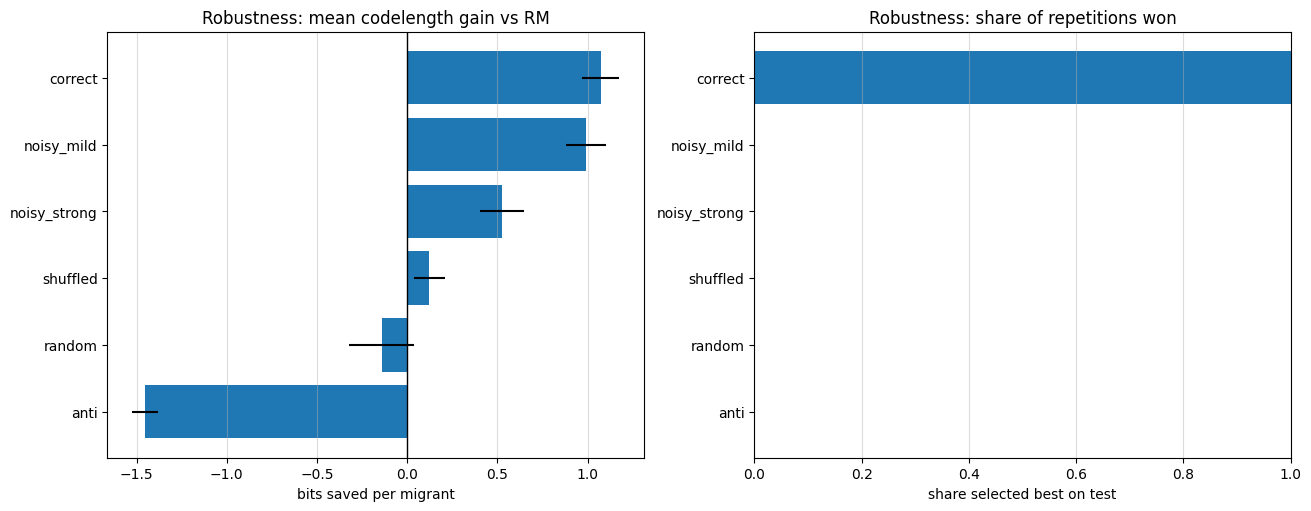

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
plot = robustness_summary.sort_values("mean_bits_saved_per_migrant")

axes[0].barh(plot["model"], plot["mean_bits_saved_per_migrant"], xerr=plot["sd_bits_saved_per_migrant"].fillna(0.0))
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Robustness: mean codelength gain vs RM")
axes[0].set_xlabel("bits saved per migrant")
axes[0].grid(True, axis="x", alpha=0.45)

axes[1].barh(plot["model"], plot["win_share"])
axes[1].set_title("Robustness: share of repetitions won")
axes[1].set_xlabel("share selected best on test")
axes[1].set_xlim(0, 1)
axes[1].grid(True, axis="x", alpha=0.45)

savefig("05_robustness")
plt.show()

## Interpretation Checklist

This toy model should be read as a controlled diagnostic.

A healthy outcome is:

- the correct feature has the lowest test codelength;
- noisy versions degrade gradually;
- shuffled, anti, and random features do not systematically beat RM;
- selected \(\sigma\) is close to the data-generating value, at least approximately;
- gains remain positive over repeated synthetic samples.

If this fails, the empirical problem is not just feature choice. It would suggest that the model, calibration, normalization, or stochastic resolution needs more work before interpreting real-data relational results.